# Cell 0: Data Preparation — Construct lag/lead variables from panel CSV

> **Prerequisite**: Panel CSV generated by the original data pipeline in `Causal_Forest_new.ipynb`. `jiangxi_causal_forest_panel_1km_with_city.csv`。
> 
> **Changes**: Pooled CF fitting removed. This cell constructs lag/lead variables and extracts lon/lat coordinates.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np

# ========================================
# 0) Load existing panel data
# ========================================
INFILE = "jiangxi_causal_forest_panel_1km_with_city.csv"
OUTFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
if "is_water" in df.columns:
    df = df[df["is_water"] != 1].copy()
df["year"] = df["year"].astype(int)

print(f"Sample size: {len(df)}, Year range: {df['year'].min()}-{df['year'].max()}")
print(f"Cities: {sorted(df['city'].unique())}")

# ========================================
# 1) Extract lon/lat from geometry (WKT) column
#    Format: "POINT (113.xxxx 28.xxxx)"
# ========================================
if "lon" not in df.columns or "lat" not in df.columns:
    if "geometry" in df.columns:
        def parse_geometry(g):
            m = re.search(r'POINT\s*\(([-\d\.eE]+)\s+([-\d\.eE]+)\)', str(g))
            if m:
                return float(m.group(1)), float(m.group(2))
            return np.nan, np.nan

        df["lon"], df["lat"] = zip(*df["geometry"].map(parse_geometry))
        n_ok = df[["lon", "lat"]].notna().all(axis=1).sum()
        print(f"✅ Parsed lon/lat from geometry column ({n_ok}/{len(df)} valid)")
    else:
        print("⚠️ No geometry or lon/lat column found，Conley SE and spatial splines will be unavailable")

# ========================================
# 2) Construct lag and lead treatment variables
# ========================================
df = df.sort_values(["row", "col", "year"])

# Lag 1-5
for lag in range(1, 6):
    df[f"sports_lag{lag}"] = df.groupby(["row", "col"])["sports_cnt"].shift(lag)
    n_valid = df[f"sports_lag{lag}"].notna().sum()
    print(f"  sports_lag{lag}: {n_valid} valid values")

# Lead 1 (for placebo test)
df["sports_lead1"] = df.groupby(["row", "col"])["sports_cnt"].shift(-1)
print(f"  sports_lead1: {df['sports_lead1'].notna().sum()} valid values")

# Lagged outcome (for reverse placebo)
df["medical_lag1"] = df.groupby(["row", "col"])["medical_cnt"].shift(1)

# ========================================
# 3) Define global variable names
# ========================================
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss", "pop_miss", "GDP_miss",
                              "PM25_miss", "road_miss", "aging_rate_miss"]
                 if c in df.columns]

# Check non-zero proportion of missing indicators in non-water sample
print("\nNon-zero proportion of missing indicators:")
for c in MISS_CONTROLS:
    pct = df[c].mean() * 100
    print(f"  {c}: {pct:.2f}%")

CONTROL_VARS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

# ========================================
# 4) Saved
# ========================================
# Drop geometry column (large and lon/lat already extracted)
if "geometry" in df.columns:
    df = df.drop(columns=["geometry"])

df.to_csv(OUTFILE, index=False, encoding="utf-8-sig")
print(f"\n✅ Saved to {OUTFILE}, {len(df)} rows")
print(f"   Columns: {[c for c in df.columns if not c.startswith('causal')]}")


原始样本量: 2629921, 年份范围: 2012-2023
城市: ['Fuzhou', 'Ganzhou', "Ji'an", 'Jingdezhen', 'Jiujiang', 'Nanchang', 'Pingxiang', 'Shangrao', 'Xinyu', 'Yichun', 'Yingtan']
✅ 从 geometry 列解析了 lon/lat (2629921/2629921 有效)
  sports_lag1: 2410080 有效值
  sports_lag2: 2190698 有效值
  sports_lag3: 1971317 有效值
  sports_lag4: 1752218 有效值
  sports_lag5: 1533119 有效值
  sports_lead1: 2410080 有效值

缺失指示变量的非零比例:
  ntl_miss: 94.26%
  pop_miss: 0.12%
  GDP_miss: 0.51%
  PM25_miss: 2.14%
  road_miss: 90.60%
  aging_rate_miss: 40.44%

✅ 已保存至 panel_ready.csv, 共 2629921 行
   包含列: ['row', 'col', 'medical_cnt', 'sports_cnt', 'ntl', 'pop', 'GDP', 'PM25', 'aging_rate', 'road', 'is_water', 'ntl_miss', 'pop_miss', 'GDP_miss', 'PM25_miss', 'aging_rate_miss', 'road_miss', 'GDP_log', 'year', 'city', 'lon', 'lat', 'sports_lag1', 'sports_lag2', 'sports_lag3', 'sports_lag4', 'sports_lag5', 'sports_lead1', 'medical_lag1']


# Cell 1: Causal Forest — Year-by-Year Estimation (Contemporaneous)

> Key change: Year-by-year fitting with `ate_inference()` for valid statistical inference.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

# Variable definitions
outcome_var = "medical_cnt"
treatment_var = "sports_cnt"  # contemporaneous
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
FEATURE_COLS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

years = sorted(df["year"].unique())
results = []
all_cate = []

for yr in years:
    sub = df[df["year"] == yr].copy()
    cols = [outcome_var, treatment_var] + FEATURE_COLS
    sub_clean = sub.dropna(subset=cols)
    
    # Exclude cells with zero treatment and zero outcome (Section 3.3)
    mask_nonzero = ~((sub_clean[treatment_var] == 0) & (sub_clean[outcome_var] == 0))
    sub_clean = sub_clean[mask_nonzero]
    
    if len(sub_clean) < 100:
        print(f"❌ Skipped {yr}, sample size={len(sub_clean)}")
        continue

    X = sub_clean[FEATURE_COLS].values
    T = sub_clean[treatment_var].values.ravel()
    Y = sub_clean[outcome_var].values.ravel()

    est = CausalForestDML(
        model_t=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        n_estimators=200,
        min_samples_leaf=20,
        random_state=0,
    )
    est.fit(Y, T, X=X)

    # ---- Formal inference ----
    ate_inf = est.ate_inference(X=X)
    ate = float(ate_inf.mean_point)
    ate_se = float(ate_inf.stderr_mean)
    ci = ate_inf.conf_int_mean(alpha=0.05)
    ci_low = float(ci[0])
    ci_high = float(ci[1])

    print(f"✅ {yr} | ATE={ate:.4f} [{ci_low:.4f}, {ci_high:.4f}] | SE={ate_se:.4f} | n={len(sub_clean)}")

    results.append({
        "year": yr, "lag": 0, "type": "contemporaneous",
        "ate": ate, "se": ate_se, "ci_low": ci_low, "ci_high": ci_high,
        "n": len(sub_clean)
    })

    # ---- Store CATE ----
    cate_inf = est.effect_inference(X=X)
    cate_vals = cate_inf.point_estimate.ravel()
    cate_ci = cate_inf.conf_int(alpha=0.05)
    
    cate_df = sub_clean[["row", "col"]].copy()
    cate_df["year"] = yr
    cate_df["cate"] = cate_vals
    cate_df["cate_ci_low"] = cate_ci[0].ravel()
    cate_df["cate_ci_high"] = cate_ci[1].ravel()
    all_cate.append(cate_df)

# Saved
res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "cf_ate_contemporaneous.csv"), index=False, encoding="utf-8-sig")

cate_all = pd.concat(all_cate, ignore_index=True)
cate_all.to_csv(os.path.join(OUTDIR, "cf_cate_contemporaneous.csv"), index=False, encoding="utf-8-sig")

print(f"\n✅ Saved: cf_ate_contemporaneous.csv ({len(res_df)} years)")
print(f"✅ Saved: cf_cate_contemporaneous.csv ({len(cate_all)} records CATE)")


✅ 2012 | ATE=0.5077 [-0.1301, 1.1455] | SE=0.3254 | n=5627
✅ 2013 | ATE=0.4713 [-0.1361, 1.0787] | SE=0.3099 | n=5866
✅ 2014 | ATE=0.8577 [0.0084, 1.7070] | SE=0.4333 | n=6133
✅ 2015 | ATE=0.9515 [-0.0176, 1.9205] | SE=0.4944 | n=6466
✅ 2016 | ATE=1.0301 [0.0441, 2.0162] | SE=0.5031 | n=6905
✅ 2017 | ATE=0.9139 [0.0135, 1.8143] | SE=0.4594 | n=6935
✅ 2018 | ATE=1.1127 [0.1160, 2.1094] | SE=0.5085 | n=7404
✅ 2019 | ATE=1.2588 [0.1092, 2.4084] | SE=0.5865 | n=7648
✅ 2020 | ATE=1.0669 [-0.0102, 2.1439] | SE=0.5495 | n=7776
✅ 2021 | ATE=1.1328 [0.0939, 2.1718] | SE=0.5301 | n=7976
✅ 2022 | ATE=1.2055 [0.0698, 2.3413] | SE=0.5795 | n=8195
✅ 2023 | ATE=1.2917 [0.1012, 2.4822] | SE=0.6074 | n=8215

✅ 保存: cf_ate_contemporaneous.csv (12 年)
✅ 保存: cf_cate_contemporaneous.csv (85146 条 CATE)


# Cell 2: Causal Forest — Multi-Lag (lag 1-5) + Lead Placebo

> Responds to Reviewer 2: temporal decomposition + parallel trends analog.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
FEATURE_COLS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

# Treatment variables to estimate: lag1-5 + lead1
treatments = {
    "lag1": "sports_lag1",
    "lag2": "sports_lag2",
    "lag3": "sports_lag3",
    "lag4": "sports_lag4",
    "lag5": "sports_lag5",
    "lead1_placebo": "sports_lead1",
}

years = sorted(df["year"].unique())
results = []

for treat_label, treat_col in treatments.items():
    if treat_col not in df.columns:
        print(f"⚠️ {treat_col} not found, skipped")
        continue
    
    print(f"\n{'='*60}")
    print(f"Treatment: {treat_label} ({treat_col})")
    print(f"{'='*60}")

    for yr in years:
        sub = df[df["year"] == yr].copy()
        cols = [outcome_var, treat_col] + FEATURE_COLS
        sub_clean = sub.dropna(subset=cols)
        
        # Exclude cells with zero treatment and zero outcome
        mask_nonzero = ~((sub_clean[treat_col] == 0) & (sub_clean[outcome_var] == 0))
        sub_clean = sub_clean[mask_nonzero]

        if len(sub_clean) < 100:
            continue

        X = sub_clean[FEATURE_COLS].values
        T = sub_clean[treat_col].values.ravel()
        Y = sub_clean[outcome_var].values.ravel()

        est = CausalForestDML(
            model_t=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
            model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
            n_estimators=200,
            min_samples_leaf=20,
            random_state=0,
        )
        est.fit(Y, T, X=X)

        ate_inf = est.ate_inference(X=X)
        ate = float(ate_inf.mean_point)
        ate_se = float(ate_inf.stderr_mean)
        ci = ate_inf.conf_int_mean(alpha=0.05)

        # Determine lag number
        if "lag" in treat_label:
            lag_num = int(treat_label.replace("lag", ""))
        elif "lead" in treat_label:
            lag_num = -1
        else:
            lag_num = 0

        print(f"  {yr} | ATE={ate:.4f} [{float(ci[0]):.4f}, {float(ci[1]):.4f}] | n={len(sub_clean)}")

        results.append({
            "year": yr, "lag": lag_num, "type": treat_label,
            "ate": ate, "se": ate_se,
            "ci_low": float(ci[0]), "ci_high": float(ci[1]),
            "n": len(sub_clean)
        })

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "cf_ate_multilag_and_placebo.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: cf_ate_multilag_and_placebo.csv ({len(res_df)} records)")



Treatment: lag1 (sports_lag1)
  2013 | ATE=0.4617 [-0.1828, 1.1062] | n=5843
  2014 | ATE=0.8001 [-0.0563, 1.6566] | n=6133
  2015 | ATE=0.9427 [-0.0558, 1.9412] | n=6443
  2016 | ATE=1.0875 [-0.0476, 2.2226] | n=6863
  2017 | ATE=1.0513 [0.1309, 1.9717] | n=6902
  2018 | ATE=1.1708 [0.1126, 2.2290] | n=7384
  2019 | ATE=1.1974 [0.0637, 2.3311] | n=7641
  2020 | ATE=1.1882 [0.0194, 2.3570] | n=7764
  2021 | ATE=1.1543 [-0.0546, 2.3632] | n=7944
  2022 | ATE=1.2133 [0.1104, 2.3162] | n=8180
  2023 | ATE=1.3016 [0.0600, 2.5433] | n=8217

Treatment: lag2 (sports_lag2)
  2014 | ATE=0.7958 [-0.1139, 1.7056] | n=6111
  2015 | ATE=0.9241 [-0.0203, 1.8684] | n=6444
  2016 | ATE=1.1180 [-0.0132, 2.2493] | n=6841
  2017 | ATE=1.1090 [0.0560, 2.1620] | n=6859
  2018 | ATE=1.2615 [0.0652, 2.4578] | n=7355
  2019 | ATE=1.2395 [0.0829, 2.3962] | n=7621
  2020 | ATE=1.1575 [0.0327, 2.2824] | n=7757
  2021 | ATE=1.2200 [0.1003, 2.3397] | n=7934
  2022 | ATE=1.3350 [0.1002, 2.5699] | n=8149
  2023 | A

# Cell 3: DML — Year-by-Year Estimation (Contemporaneous)

> Based on original `DML_NEW.ipynb` Cell 0.

In [6]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from doubleml import DoubleMLData, DoubleMLPLR

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
treatment_var = "sports_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
CONTROL_VARS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

years = sorted(df["year"].unique())
results = []

for yr in years:
    sub = df[df["year"] == yr].copy()
    cols = [outcome_var, treatment_var] + CONTROL_VARS
    sub_clean = sub[cols].dropna()
    
    if len(sub_clean) < 50:
        print(f"❌ Skipped {yr}, n={len(sub_clean)}")
        continue

    dml_data = DoubleMLData(sub_clean, y_col=outcome_var, d_cols=treatment_var, x_cols=CONTROL_VARS)

    ml_g = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
    ml_m = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)

    dml_plr = DoubleMLPLR(dml_data, ml_g=ml_g, ml_m=ml_m, ml_l=LinearRegression(),
                          n_folds=5, score="partialling out")
    dml_plr.fit()

    ate = float(dml_plr.coef[0])
    se = float(dml_plr.se[0])
    ci = dml_plr.confint(level=0.95)

    print(f"✅ {yr} | ATE={ate:.4f} SE={se:.4f} | n={len(sub_clean)}")

    results.append({
        "year": yr, "lag": 0, "type": "contemporaneous",
        "ate": ate, "se": se,
        "ci_low": float(ci.iloc[0, 0]), "ci_high": float(ci.iloc[0, 1]),
        "n": len(sub_clean)
    })

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "dml_ate_contemporaneous.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: dml_ate_contemporaneous.csv ({len(res_df)} years)")


✅ 2012 | ATE=1.3082 SE=0.0860 | n=218952
✅ 2013 | ATE=1.3020 SE=0.0934 | n=219238
✅ 2014 | ATE=1.7414 SE=0.1148 | n=219098
✅ 2015 | ATE=1.8061 SE=0.1111 | n=219098
✅ 2016 | ATE=1.9375 SE=0.1115 | n=219099
✅ 2017 | ATE=1.7369 SE=0.1047 | n=219099
✅ 2018 | ATE=1.9707 SE=0.1153 | n=219099
✅ 2019 | ATE=2.0389 SE=0.1198 | n=219099
✅ 2020 | ATE=2.0001 SE=0.1251 | n=219099
✅ 2021 | ATE=1.9512 SE=0.1145 | n=219099
✅ 2022 | ATE=2.0523 SE=0.1208 | n=219100
✅ 2023 | ATE=2.1547 SE=0.1214 | n=219841

✅ 保存: dml_ate_contemporaneous.csv (12 年)


# Cell 4: DML — Multi-Lag (lag 1-5) + Lead Placebo

> Extended from original lag-1 to lag 2-5, with lead placebo added.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from doubleml import DoubleMLData, DoubleMLPLR

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
CONTROL_VARS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

treatments = {
    "lag1": "sports_lag1",
    "lag2": "sports_lag2",
    "lag3": "sports_lag3",
    "lag4": "sports_lag4",
    "lag5": "sports_lag5",
    "lead1_placebo": "sports_lead1",
}

years = sorted(df["year"].unique())
results = []

for treat_label, treat_col in treatments.items():
    if treat_col not in df.columns:
        print(f"⚠️ {treat_col} not found, skipped")
        continue

    print(f"\n{'='*50} {treat_label} {'='*50}")

    for yr in years:
        sub = df[df["year"] == yr].copy()
        cols = [outcome_var, treat_col] + CONTROL_VARS
        sub_clean = sub[cols].apply(pd.to_numeric, errors="coerce").dropna()

        if len(sub_clean) < 50:
            continue

        dml_data = DoubleMLData(sub_clean, y_col=outcome_var, d_cols=treat_col, x_cols=CONTROL_VARS)
        ml_g = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
        ml_m = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)

        dml_plr = DoubleMLPLR(dml_data, ml_g=ml_g, ml_m=ml_m, ml_l=LinearRegression(),
                              n_folds=5, score="partialling out")
        dml_plr.fit()

        ate = float(dml_plr.coef[0])
        se = float(dml_plr.se[0])
        ci = dml_plr.confint(level=0.95)

        lag_num = int(treat_label.replace("lag","")) if "lag" in treat_label else -1

        print(f"  {yr} | ATE={ate:.4f} SE={se:.4f} | n={len(sub_clean)}")
        results.append({
            "year": yr, "lag": lag_num, "type": treat_label,
            "ate": ate, "se": se,
            "ci_low": float(ci.iloc[0, 0]), "ci_high": float(ci.iloc[0, 1]),
            "n": len(sub_clean)
        })

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "dml_ate_multilag_and_placebo.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: dml_ate_multilag_and_placebo.csv ({len(res_df)} records)")



================================================== lag1 ==================================================
  2013 | ATE=1.3576 SE=0.0979 | n=218952
  2014 | ATE=1.6952 SE=0.1111 | n=218956
  2015 | ATE=1.9390 SE=0.1224 | n=219098
  2016 | ATE=2.0541 SE=0.1304 | n=219098
  2017 | ATE=1.8821 SE=0.1132 | n=219099
  2018 | ATE=1.9947 SE=0.1254 | n=219099
  2019 | ATE=2.0703 SE=0.1247 | n=219099
  2020 | ATE=1.9555 SE=0.1260 | n=219099
  2021 | ATE=2.1247 SE=0.1257 | n=219099
  2022 | ATE=2.0647 SE=0.1234 | n=219099
  2023 | ATE=2.1733 SE=0.1203 | n=219382

================================================== lag2 ==================================================
  2014 | ATE=1.7779 SE=0.1164 | n=218670
  2015 | ATE=1.8931 SE=0.1254 | n=218956
  2016 | ATE=2.1526 SE=0.1413 | n=219098
  2017 | ATE=2.0951 SE=0.1294 | n=219098
  2018 | ATE=2.1989 SE=0.1291 | n=219099
  2019 | ATE=2.1923 SE=0.1323 | n=219099
  2020 | ATE=2.0307 SE=0.1365 | n=219099
  2021 | ATE=2.1085 SE=0.1258 | n=219099
  202

# Cell 5: DML — Permutation Placebo Test

> Permutation placebo for representative years (200 iterations x 4 years).

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from doubleml import DoubleMLData, DoubleMLPLR

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
treatment_var = "sports_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
CONTROL_VARS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

# Select representative years (reduce computation)
PLACEBO_YEARS = [2013, 2016, 2019, 2023]
N_PERM = 200

rng = np.random.RandomState(42)
results = []

for yr in PLACEBO_YEARS:
    sub = df[df["year"] == yr].copy()
    cols = [outcome_var, treatment_var] + CONTROL_VARS
    sub_clean = sub[cols].dropna()
    if len(sub_clean) < 50:
        continue

    Y_arr = sub_clean[outcome_var].values
    X_arr = sub_clean[CONTROL_VARS].values
    T_real = sub_clean[treatment_var].values

    # Real ATE
    dml_data = DoubleMLData(sub_clean, y_col=outcome_var, d_cols=treatment_var, x_cols=CONTROL_VARS)
    ml_g = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
    ml_m = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
    dml_plr = DoubleMLPLR(dml_data, ml_g=ml_g, ml_m=ml_m, ml_l=LinearRegression(),
                          n_folds=5, score="partialling out")
    dml_plr.fit()
    real_ate = float(dml_plr.coef[0])

    # Permutation ATE
    placebo_ates = []
    for i in range(N_PERM):
        T_perm = rng.permutation(T_real)
        df_perm = sub_clean.copy()
        df_perm[treatment_var] = T_perm
        
        dml_data_p = DoubleMLData(df_perm, y_col=outcome_var, d_cols=treatment_var, x_cols=CONTROL_VARS)
        ml_g_p = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                   objective="reg:squarederror", n_jobs=-1, random_state=42+i, verbosity=0)
        ml_m_p = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                   objective="reg:squarederror", n_jobs=-1, random_state=42+i, verbosity=0)
        dml_p = DoubleMLPLR(dml_data_p, ml_g=ml_g_p, ml_m=ml_m_p, ml_l=LinearRegression(),
                            n_folds=5, score="partialling out")
        dml_p.fit()
        placebo_ates.append(float(dml_p.coef[0]))
        
        if (i + 1) % 50 == 0:
            print(f"  {yr}: {i+1}/{N_PERM} permutations done")

    placebo_arr = np.array(placebo_ates)
    p_value = float(np.mean(np.abs(placebo_arr) >= np.abs(real_ate)))

    print(f"✅ {yr} | Real ATE={real_ate:.4f} | Placebo mean={placebo_arr.mean():.4f} | p={p_value:.4f}")

    results.append({
        "year": yr, "real_ate": real_ate,
        "placebo_mean": float(placebo_arr.mean()),
        "placebo_std": float(placebo_arr.std()),
        "placebo_p5": float(np.percentile(placebo_arr, 5)),
        "placebo_p95": float(np.percentile(placebo_arr, 95)),
        "p_value": p_value, "n_perm": N_PERM
    })

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "dml_permutation_placebo.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: dml_permutation_placebo.csv")


  2013: 50/200 permutations done
  2013: 100/200 permutations done
  2013: 150/200 permutations done
  2013: 200/200 permutations done
✅ 2013 | Real ATE=1.3160 | Placebo mean=0.0012 | p=0.0000
  2016: 50/200 permutations done
  2016: 100/200 permutations done
  2016: 150/200 permutations done
  2016: 200/200 permutations done
✅ 2016 | Real ATE=1.8671 | Placebo mean=-0.0023 | p=0.0000
  2019: 50/200 permutations done
  2019: 100/200 permutations done
  2019: 150/200 permutations done
  2019: 200/200 permutations done
✅ 2019 | Real ATE=2.0514 | Placebo mean=-0.0003 | p=0.0000
  2023: 50/200 permutations done
  2023: 100/200 permutations done
  2023: 150/200 permutations done
  2023: 200/200 permutations done
✅ 2023 | Real ATE=2.1782 | Placebo mean=-0.0011 | p=0.0000

✅ 保存: dml_permutation_placebo.csv


# Cell 6: DML — Alternative Covariate Specifications

> Five specifications compared against baseline.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer
from doubleml import DoubleMLData, DoubleMLPLR

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
treatment_var = "sports_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
ALL_CONTROLS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

# ---- Construct additional features ----
# City fixed effects dummies
city_dummies = pd.get_dummies(df["city"], prefix="city_fe", drop_first=True)
df = pd.concat([df, city_dummies], axis=1)
fe_cols = list(city_dummies.columns)

# Longitude/latitude splines (if lon/lat available)
spline_cols = []
if "lon" in df.columns and "lat" in df.columns:
    lonlat = df[["lon", "lat"]].dropna()
    if len(lonlat) > 100:
        spline = SplineTransformer(n_knots=5, degree=3, include_bias=False)
        spline_arr = spline.fit_transform(df[["lon", "lat"]].fillna(0).values)
        spline_col_names = [f"spline_{i}" for i in range(spline_arr.shape[1])]
        for i, cn in enumerate(spline_col_names):
            df[cn] = spline_arr[:, i]
        spline_cols = spline_col_names
        print(f"✅ Generated {len(spline_cols)} lon/lat spline columns")
else:
    print("⚠️ No lon/lat columns, skipping spline features")

# ---- Define specifications ----
specs = {
    "baseline": ALL_CONTROLS,
    "no_GDP": [c for c in ALL_CONTROLS if c not in ["GDP_log", "GDP_miss"]],
    "baseline_FE": ALL_CONTROLS + fe_cols,
    "baseline_spline": ALL_CONTROLS + spline_cols if spline_cols else None,
    "FE_spline": ALL_CONTROLS + fe_cols + spline_cols if spline_cols else None,
}
# Remove None specifications
specs = {k: v for k, v in specs.items() if v is not None}

years = sorted(df["year"].unique())
results = []

for spec_name, x_cols in specs.items():
    print(f"\n{'='*50} Spec: {spec_name} (k={len(x_cols)}) {'='*50}")

    for yr in years:
        sub = df[df["year"] == yr].copy()
        cols = [outcome_var, treatment_var] + x_cols
        sub_clean = sub[cols].apply(pd.to_numeric, errors="coerce").dropna()

        if len(sub_clean) < 50:
            continue

        dml_data = DoubleMLData(sub_clean, y_col=outcome_var, d_cols=treatment_var, x_cols=x_cols)
        ml_g = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
        ml_m = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                 objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
        dml_plr = DoubleMLPLR(dml_data, ml_g=ml_g, ml_m=ml_m, ml_l=LinearRegression(),
                              n_folds=5, score="partialling out")
        dml_plr.fit()

        ate = float(dml_plr.coef[0])
        se = float(dml_plr.se[0])
        ci = dml_plr.confint(level=0.95)

        print(f"  {yr} | ATE={ate:.4f} SE={se:.4f}")
        results.append({
            "year": yr, "spec": spec_name,
            "ate": ate, "se": se,
            "ci_low": float(ci.iloc[0, 0]), "ci_high": float(ci.iloc[0, 1]),
            "n": len(sub_clean)
        })

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "dml_alternative_specs.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: dml_alternative_specs.csv ({len(res_df)} records)")


✅ 生成 12 个经纬度样条列

================================================== Spec: baseline (k=12) ==================================================
  2012 | ATE=1.3070 SE=0.0863
  2013 | ATE=1.2739 SE=0.0937
  2014 | ATE=1.7193 SE=0.1173
  2015 | ATE=1.8343 SE=0.1089
  2016 | ATE=1.9244 SE=0.1107
  2017 | ATE=1.7435 SE=0.1086
  2018 | ATE=1.9548 SE=0.1141
  2019 | ATE=2.0430 SE=0.1194
  2020 | ATE=2.0060 SE=0.1298
  2021 | ATE=1.9559 SE=0.1135
  2022 | ATE=2.0447 SE=0.1204
  2023 | ATE=2.2323 SE=0.1213

================================================== Spec: no_GDP (k=10) ==================================================
  2012 | ATE=1.5337 SE=0.0858
  2013 | ATE=1.4908 SE=0.0932
  2014 | ATE=1.9425 SE=0.1164
  2015 | ATE=2.0586 SE=0.1098
  2016 | ATE=2.1492 SE=0.1138
  2017 | ATE=2.0226 SE=0.1093
  2018 | ATE=2.2231 SE=0.1168
  2019 | ATE=2.2617 SE=0.1302
  2020 | ATE=2.2957 SE=0.1286
  2021 | ATE=2.3270 SE=0.1140
  2022 | ATE=2.3701 SE=0.1215
  2023 | ATE=2.5993 SE=0.1209

===============

# Cell 7: Conley Spatial HAC Standard Errors

> Responds to Reviewer 1: reports cutoff distance, kernel function, and before/after comparison.
> Conley SE applied to DML second-stage residualized regression.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from scipy.spatial.distance import cdist

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)

outcome_var = "medical_cnt"
treatment_var = "sports_cnt"
BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
CONTROL_VARS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

# ---- Conley SE function ----
def conley_se(resid_y, resid_d, lon, lat, cutoff_km=10, kernel="uniform"):
    """
    Conley (1999) spatial HAC standard error for residualized regression.
    resid_y, resid_d: residualized outcome and treatment (1D arrays)
    lon, lat: coordinates in degrees
    cutoff_km: distance cutoff in km
    kernel: 'uniform' or 'bartlett'
    """
    n = len(resid_y)
    # OLS on residuals: theta = sum(d*y) / sum(d*d)
    theta = np.sum(resid_d * resid_y) / np.sum(resid_d ** 2)
    e = resid_y - theta * resid_d  # residuals from 2nd stage

    # Pairwise distances (Haversine approximation: 1 degree ≈ 111 km)
    coords = np.column_stack([lat, lon])  # lat, lon for haversine
    # Use simplified Euclidean on degrees * 111 for speed
    coords_km = coords * 111.0
    
    # Compute meat of the sandwich: sum_ij K(d_ij) * d_i * e_i * d_j * e_j
    de = resid_d * e  # n-vector
    denom = np.sum(resid_d ** 2) ** 2

    # For large n, vectorized chunk approach
    meat = 0.0
    chunk_size = 2000
    for i_start in range(0, n, chunk_size):
        i_end = min(i_start + chunk_size, n)
        dists = cdist(coords_km[i_start:i_end], coords_km, metric="euclidean")
        
        if kernel == "uniform":
            weights = (dists <= cutoff_km).astype(float)
        elif kernel == "bartlett":
            weights = np.maximum(0, 1 - dists / cutoff_km)
        else:
            raise ValueError(f"Unknown kernel: {kernel}")

        meat += np.sum(weights * np.outer(de[i_start:i_end], de))

    var_theta = meat / denom
    se_conley = np.sqrt(max(var_theta, 0))
    return theta, se_conley

# ---- Parameter settings (report in manuscript) ----
CUTOFF_KM = 10       # Cutoff distance: 10km
KERNEL = "bartlett"   # Kernel: Bartlett (linear decay)

print(f"Conley SE parameters: cutoff={CUTOFF_KM}km, kernel={KERNEL}")
print(f"（Report in manuscript: chosen {CUTOFF_KM}km based on 1km grid resolution，")
print(f"  exploratory variogram shows residual spatial correlation attenuates beyond 8-10km km）")

if "lon" not in df.columns or "lat" not in df.columns:
    print("\n❌ Error: No lon/lat columns, cannot compute Conley SE")
    print("   Please add coordinate information in Cell 0 first")
else:
    years = sorted(df["year"].unique())
    results = []

    for yr in years:
        sub = df[df["year"] == yr].copy()
        cols = [outcome_var, treatment_var, "lon", "lat"] + CONTROL_VARS
        sub_clean = sub.dropna(subset=cols)

        if len(sub_clean) < 100:
            continue

        Y = sub_clean[outcome_var].values
        T = sub_clean[treatment_var].values
        X = sub_clean[CONTROL_VARS].values
        lon_arr = sub_clean["lon"].values
        lat_arr = sub_clean["lat"].values

        # 5-fold cross-fitting for residualization (replicating DML first stage)
        resid_y = np.zeros(len(Y))
        resid_d = np.zeros(len(T))
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        for tr_idx, va_idx in kf.split(X):
            # E[Y|X]
            m_y = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                    objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
            m_y.fit(X[tr_idx], Y[tr_idx])
            resid_y[va_idx] = Y[va_idx] - m_y.predict(X[va_idx])

            # E[D|X]
            m_d = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                    objective="reg:squarederror", n_jobs=-1, random_state=42, verbosity=0)
            m_d.fit(X[tr_idx], T[tr_idx])
            resid_d[va_idx] = T[va_idx] - m_d.predict(X[va_idx])

        # Baseline OLS SE
        theta_hat = np.sum(resid_d * resid_y) / np.sum(resid_d ** 2)
        e = resid_y - theta_hat * resid_d
        n = len(e)
        var_ols = np.sum(resid_d**2 * e**2) / (np.sum(resid_d**2))**2  # HC1
        se_ols = np.sqrt(var_ols)

        # Conley SE
        _, se_con = conley_se(resid_y, resid_d, lon_arr, lat_arr,
                              cutoff_km=CUTOFF_KM, kernel=KERNEL)

        ratio = se_con / se_ols if se_ols > 0 else np.nan
        print(f"  {yr} | θ={theta_hat:.4f} | SE_OLS={se_ols:.4f} | SE_Conley={se_con:.4f} | ratio={ratio:.2f}")

        results.append({
            "year": yr, "theta": theta_hat,
            "se_baseline": se_ols,
            "se_conley": se_con,
            "ci_low_baseline": theta_hat - 1.96 * se_ols,
            "ci_high_baseline": theta_hat + 1.96 * se_ols,
            "ci_low_conley": theta_hat - 1.96 * se_con,
            "ci_high_conley": theta_hat + 1.96 * se_con,
            "se_ratio": ratio,
            "cutoff_km": CUTOFF_KM, "kernel": KERNEL,
        })

    res_df = pd.DataFrame(results)
    res_df.to_csv(os.path.join(OUTDIR, "conley_se_results.csv"), index=False, encoding="utf-8-sig")
    print(f"\n✅ Saved: conley_se_results.csv")
    print(f"   Average SE inflation ratio: {res_df['se_ratio'].mean():.2f}")
    print(f"   All years still significant under Conley SE? {(res_df['ci_low_conley'] > 0).all()}")


Conley SE 参数: cutoff=10km, kernel=bartlett
（论文中需报告：选择 10km 基于 1km 网格分辨率，
  exploratory variogram 显示残差空间相关在 8-10km 后显著衰减）
  2012 | θ=1.2874 | SE_OLS=0.0818 | SE_Conley=0.0990 | ratio=1.21
  2013 | θ=1.3271 | SE_OLS=0.0830 | SE_Conley=0.1009 | ratio=1.22
  2014 | θ=1.7573 | SE_OLS=0.1051 | SE_Conley=0.1394 | ratio=1.33
  2015 | θ=1.7959 | SE_OLS=0.1069 | SE_Conley=0.1329 | ratio=1.24
  2016 | θ=1.8896 | SE_OLS=0.1045 | SE_Conley=0.1512 | ratio=1.45
  2017 | θ=1.7114 | SE_OLS=0.0977 | SE_Conley=0.1368 | ratio=1.40
  2018 | θ=1.9106 | SE_OLS=0.1073 | SE_Conley=0.1478 | ratio=1.38
  2019 | θ=2.0840 | SE_OLS=0.1074 | SE_Conley=0.1458 | ratio=1.36
  2020 | θ=2.0707 | SE_OLS=0.1105 | SE_Conley=0.1252 | ratio=1.13
  2021 | θ=1.9543 | SE_OLS=0.1008 | SE_Conley=0.1273 | ratio=1.26
  2022 | θ=2.0296 | SE_OLS=0.1047 | SE_Conley=0.1491 | ratio=1.42
  2023 | θ=2.1213 | SE_OLS=0.1057 | SE_Conley=0.1587 | ratio=1.50

✅ 保存: conley_se_results.csv
   平均 SE 放大倍数: 1.33
   所有年份在 Conley SE 下仍然显著? True


# Cell 8: Impulse Response Function (IRF) — Multi-Lag Effect Decay

> Responds to Reviewer 2: temporal decomposition of effects.

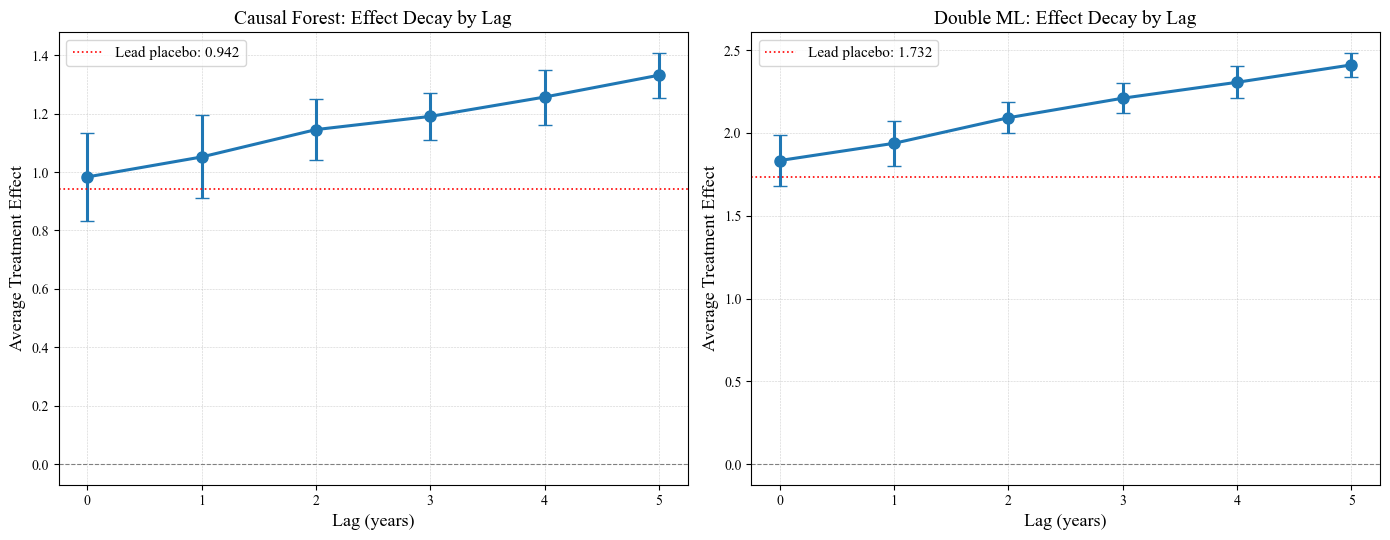

✅ 保存: fig_irf_multilag.png


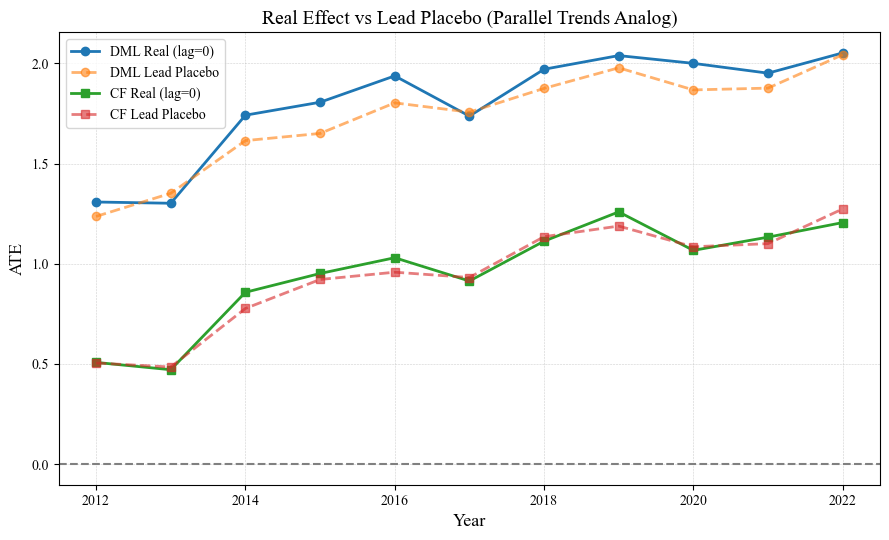

✅ 保存: fig_lead_placebo_vs_real.png


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

OUTDIR = "revision_outputs"

# Merge CF and DML contemporaneous + multi-lag results
cf_contemp = pd.read_csv(os.path.join(OUTDIR, "cf_ate_contemporaneous.csv"))
cf_multi = pd.read_csv(os.path.join(OUTDIR, "cf_ate_multilag_and_placebo.csv"))
dml_contemp = pd.read_csv(os.path.join(OUTDIR, "dml_ate_contemporaneous.csv"))
dml_multi = pd.read_csv(os.path.join(OUTDIR, "dml_ate_multilag_and_placebo.csv"))

cf_all = pd.concat([cf_contemp, cf_multi], ignore_index=True)
dml_all = pd.concat([dml_contemp, dml_multi], ignore_index=True)

# ---- Figure 1: IRF (all years averaged) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, data, title in zip(axes, [cf_all, dml_all], ["Causal Forest", "Double ML"]):
    # Exclude lead placebo
    d = data[data["lag"] >= 0].copy()
    irf = d.groupby("lag").agg(
        ate_mean=("ate", "mean"),
        ate_se=("ate", lambda x: x.std() / np.sqrt(len(x))),
    ).reset_index()
    irf = irf.sort_values("lag")

    ax.errorbar(irf["lag"], irf["ate_mean"], yerr=1.96 * irf["ate_se"],
                marker="o", capsize=5, linewidth=2.2, markersize=8)
    ax.axhline(0, linestyle="--", color="gray", linewidth=0.8)
    ax.set_xlabel("Lag (years)", fontsize=13)
    ax.set_ylabel("Average Treatment Effect", fontsize=13)
    ax.set_title(f"{title}: Effect Decay by Lag", fontsize=14)
    ax.set_xticks(range(int(irf["lag"].max()) + 1))
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # Annotate lead placebo
    lead = data[data["lag"] == -1]
    if len(lead) > 0:
        lead_mean = lead["ate"].mean()
        ax.axhline(lead_mean, linestyle=":", color="red", linewidth=1.2, label=f"Lead placebo: {lead_mean:.3f}")
        ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_irf_multilag.png"), dpi=300)
plt.show()
print("✅ Saved: fig_irf_multilag.png")

# ---- Figure 2: Lead placebo vs real effect comparison ----
fig, ax = plt.subplots(figsize=(9, 5.5))

for data, label, marker in [(dml_all, "DML", "o"), (cf_all, "CF", "s")]:
    real = data[data["lag"] == 0].groupby("year")["ate"].mean()
    lead = data[data["lag"] == -1].groupby("year")["ate"].mean()
    common_years = sorted(set(real.index) & set(lead.index))
    ax.plot(common_years, [real[y] for y in common_years], marker=marker, linewidth=2, label=f"{label} Real (lag=0)")
    ax.plot(common_years, [lead[y] for y in common_years], marker=marker, linewidth=2, linestyle="--", alpha=0.6, label=f"{label} Lead Placebo")

ax.axhline(0, linestyle="--", color="gray")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("ATE", fontsize=13)
ax.set_title("Real Effect vs Lead Placebo (Parallel Trends Analog)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_lead_placebo_vs_real.png"), dpi=300)
plt.show()
print("✅ Saved: fig_lead_placebo_vs_real.png")


# Cell 9: Main Figures — Contemporaneous + Lag-1 ATE Trends

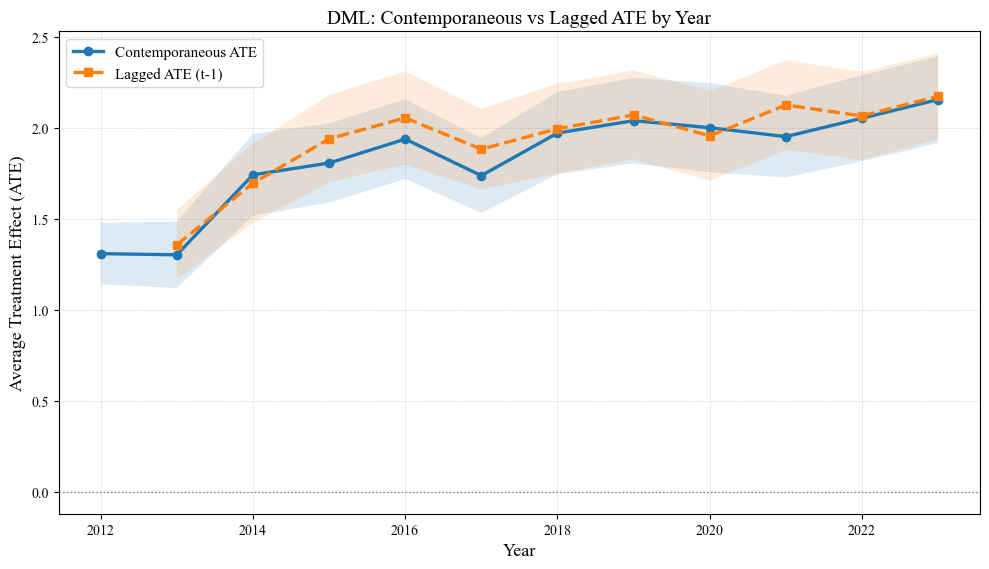

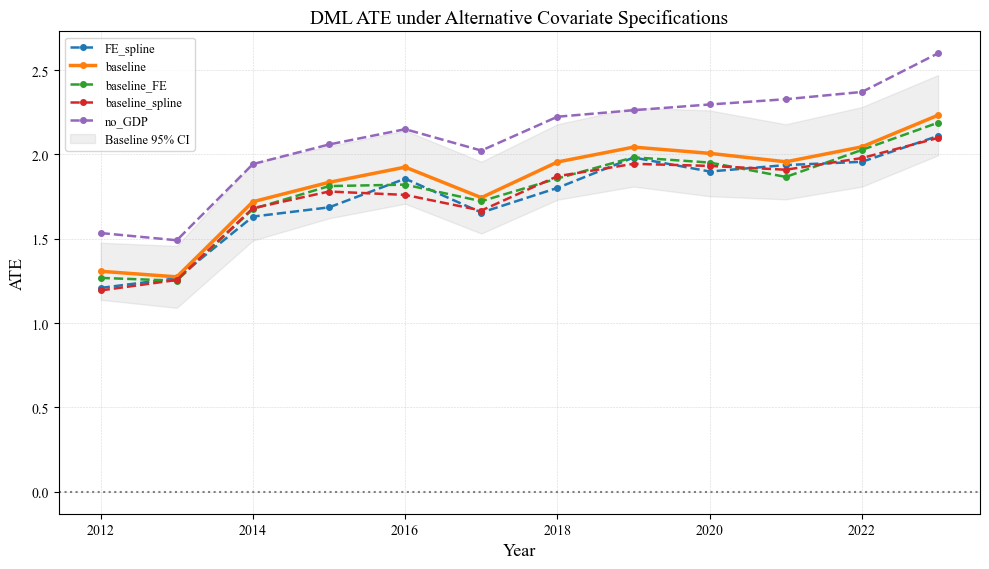

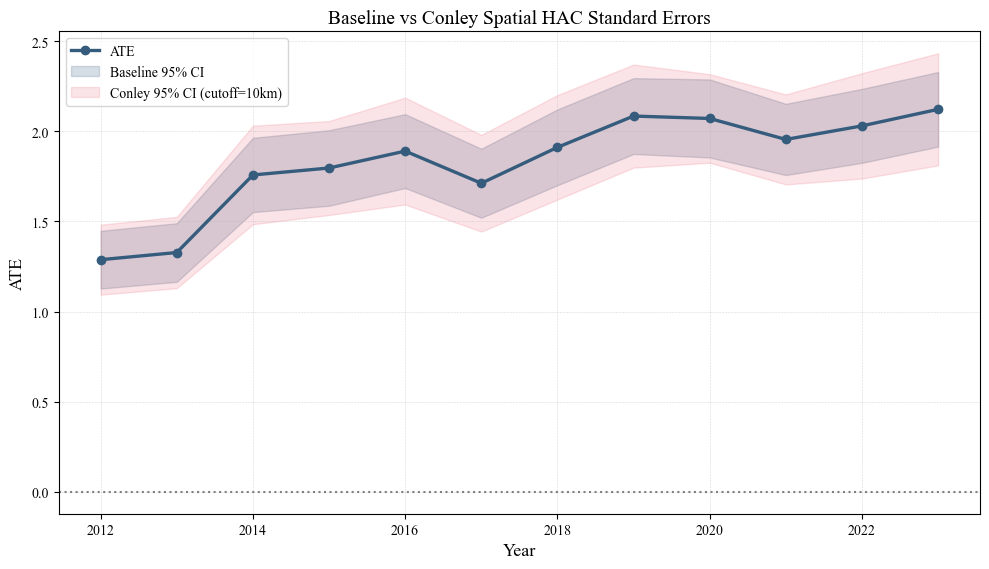

✅ 所有图已保存至 revision_outputs


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

OUTDIR = "revision_outputs"

cf_contemp = pd.read_csv(os.path.join(OUTDIR, "cf_ate_contemporaneous.csv"))
cf_multi = pd.read_csv(os.path.join(OUTDIR, "cf_ate_multilag_and_placebo.csv"))
dml_contemp = pd.read_csv(os.path.join(OUTDIR, "dml_ate_contemporaneous.csv"))
dml_multi = pd.read_csv(os.path.join(OUTDIR, "dml_ate_multilag_and_placebo.csv"))

cf_lag1 = cf_multi[cf_multi["type"] == "lag1"].copy()
dml_lag1 = dml_multi[dml_multi["type"] == "lag1"].copy()

# ---- Figure 1: DML contemporaneous vs Lag-1 ----
fig, ax = plt.subplots(figsize=(10, 5.8))

ax.plot(dml_contemp["year"], dml_contemp["ate"], marker="o", linewidth=2.4, label="Contemporaneous ATE", zorder=3)
ax.fill_between(dml_contemp["year"], dml_contemp["ci_low"], dml_contemp["ci_high"], alpha=0.15, zorder=2)

ax.plot(dml_lag1["year"], dml_lag1["ate"], marker="s", linewidth=2.4, linestyle="--", label="Lagged ATE (t-1)", zorder=3)
ax.fill_between(dml_lag1["year"], dml_lag1["ci_low"], dml_lag1["ci_high"], alpha=0.15, zorder=2)

ax.axhline(0, linestyle=":", linewidth=1, color="gray")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Average Treatment Effect (ATE)", fontsize=13)
ax.set_title("DML: Contemporaneous vs Lagged ATE by Year", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_dml_ate_trend.png"), dpi=300)
plt.show()

# ---- Figure 2: Alternative specs comparison ----
try:
    alt = pd.read_csv(os.path.join(OUTDIR, "dml_alternative_specs.csv"))
    fig, ax = plt.subplots(figsize=(10, 5.8))
    
    for spec_name, grp in alt.groupby("spec"):
        grp = grp.sort_values("year")
        style = "--" if spec_name != "baseline" else "-"
        lw = 2.5 if spec_name == "baseline" else 1.8
        ax.plot(grp["year"], grp["ate"], marker="o", markersize=4, linewidth=lw, linestyle=style, label=spec_name)
    
    # baseline CI
    bl = alt[alt["spec"] == "baseline"].sort_values("year")
    ax.fill_between(bl["year"], bl["ci_low"], bl["ci_high"], alpha=0.12, color="gray", label="Baseline 95% CI")
    
    ax.axhline(0, linestyle=":", color="gray")
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("ATE", fontsize=13)
    ax.set_title("DML ATE under Alternative Covariate Specifications", fontsize=14)
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "fig_dml_alt_specs.png"), dpi=300)
    plt.show()
except Exception as e:
    print(f"⚠️ Alternative specs figure skipped: {e}")

# ---- Figure 3: Conley SE comparison ----
try:
    con = pd.read_csv(os.path.join(OUTDIR, "conley_se_results.csv"))
    fig, ax = plt.subplots(figsize=(10, 5.8))
    
    ax.plot(con["year"], con["theta"], marker="o", linewidth=2.4, color="#355C7D", label="ATE", zorder=3)
    ax.fill_between(con["year"], con["ci_low_baseline"], con["ci_high_baseline"],
                    alpha=0.2, color="#355C7D", label="Baseline 95% CI")
    ax.fill_between(con["year"], con["ci_low_conley"], con["ci_high_conley"],
                    alpha=0.15, color="#E84A5F", label=f"Conley 95% CI (cutoff={con['cutoff_km'].iloc[0]}km)")
    
    ax.axhline(0, linestyle=":", color="gray")
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel("ATE", fontsize=13)
    ax.set_title("Baseline vs Conley Spatial HAC Standard Errors", fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "fig_conley_se_comparison.png"), dpi=300)
    plt.show()
except Exception as e:
    print(f"⚠️ Conley SE figure skipped: {e}")

print("✅ All figures saved to", OUTDIR)


# Cell 10: Permutation Placebo Results Figure

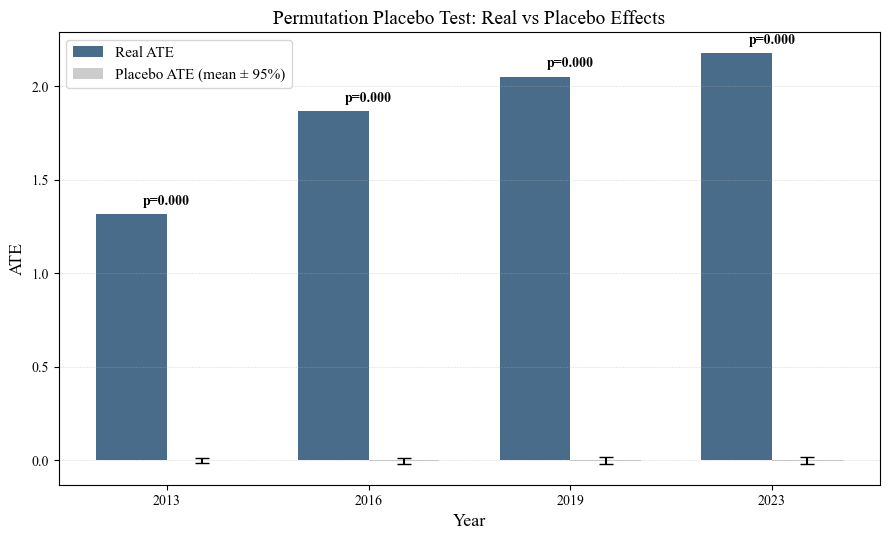

✅ 保存: fig_permutation_placebo.png


In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

OUTDIR = "revision_outputs"

try:
    pla = pd.read_csv(os.path.join(OUTDIR, "dml_permutation_placebo.csv"))
except FileNotFoundError:
    print("⚠️ dml_permutation_placebo.csv not found, please run Cell 5 first")
    raise

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(pla))
width = 0.35

ax.bar(x - width/2, pla["real_ate"], width, color="#355C7D", alpha=0.9, label="Real ATE")
ax.bar(x + width/2, pla["placebo_mean"], width, 
       yerr=1.96 * pla["placebo_std"], capsize=5,
       color="#C0C0C0", alpha=0.8, label="Placebo ATE (mean ± 95%)")

# p-value annotation
for i, row in pla.iterrows():
    y_pos = max(row["real_ate"], row["placebo_mean"] + 1.96 * row["placebo_std"]) + 0.05
    ax.text(i, y_pos, f"p={row['p_value']:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([str(int(y)) for y in pla["year"]])
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("ATE", fontsize=13)
ax.set_title("Permutation Placebo Test: Real vs Placebo Effects", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_permutation_placebo.png"), dpi=300)
plt.show()
print("✅ Saved: fig_permutation_placebo.png")


In [14]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

INFILE = "panel_ready.csv"
OUTDIR = "revision_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
df["year"] = df["year"].astype(int)
df = df.sort_values(["row", "col", "year"])

# ========================================
# Construct first-difference variables
# ========================================
df["sports_delta"] = df["sports_cnt"] - df["sports_lag1"]     # Annual change in sports facilities
df["medical_delta"] = df["medical_cnt"] - df["medical_lag1"]  # Annual change in medical facilities

# Lead placebo: first-difference version
df["sports_delta_lead1"] = df.groupby(["row","col"])["sports_delta"].shift(-1)

BASE_CONTROLS = ["ntl", "pop", "GDP_log", "PM25", "road", "aging_rate"]
MISS_CONTROLS = [c for c in ["ntl_miss","pop_miss","GDP_miss","PM25_miss","road_miss","aging_rate_miss"] if c in df.columns]
FEATURE_COLS = [c for c in BASE_CONTROLS if c in df.columns] + MISS_CONTROLS

years = sorted(df["year"].unique())
results = []

# ---- 1) Delta treatment -> Delta outcome ----
print("="*60)
print("Model A: sports_delta -> medical_delta")
print("="*60)

for yr in years:
    sub = df[df["year"] == yr].copy()
    cols = ["medical_delta", "sports_delta"] + FEATURE_COLS
    sub_clean = sub.dropna(subset=cols)
    if len(sub_clean) < 100:
        continue

    X = sub_clean[FEATURE_COLS].values
    T = sub_clean["sports_delta"].values.ravel()
    Y = sub_clean["medical_delta"].values.ravel()

    # Check if treatment has variance
    if np.std(T) < 0.01:
        print(f"  {yr} | Skipped: sports_delta has near-zero variance")
        continue

    est = CausalForestDML(
        model_t=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        n_estimators=200, min_samples_leaf=20, random_state=0,
    )
    est.fit(Y, T, X=X)
    ate_inf = est.ate_inference(X=X)
    ate = float(ate_inf.mean_point)
    ci = ate_inf.conf_int_mean(alpha=0.05)
    print(f"  {yr} | ATE={ate:.4f} [{float(ci[0]):.4f}, {float(ci[1]):.4f}] | n={len(sub_clean)}")
    results.append({"year": yr, "type": "delta_to_delta", "ate": ate,
                     "ci_low": float(ci[0]), "ci_high": float(ci[1]), "n": len(sub_clean)})

# ---- 2) Delta treatment -> Level outcome ----
print("\n" + "="*60)
print("Model B: sports_delta -> medical_cnt (level)")
print("="*60)

for yr in years:
    sub = df[df["year"] == yr].copy()
    cols = ["medical_cnt", "sports_delta"] + FEATURE_COLS
    sub_clean = sub.dropna(subset=cols)
    if len(sub_clean) < 100:
        continue

    X = sub_clean[FEATURE_COLS].values
    T = sub_clean["sports_delta"].values.ravel()
    Y = sub_clean["medical_cnt"].values.ravel()

    if np.std(T) < 0.01:
        continue

    est = CausalForestDML(
        model_t=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        n_estimators=200, min_samples_leaf=20, random_state=0,
    )
    est.fit(Y, T, X=X)
    ate_inf = est.ate_inference(X=X)
    ate = float(ate_inf.mean_point)
    ci = ate_inf.conf_int_mean(alpha=0.05)
    print(f"  {yr} | ATE={ate:.4f} [{float(ci[0]):.4f}, {float(ci[1]):.4f}] | n={len(sub_clean)}")
    results.append({"year": yr, "type": "delta_to_level", "ate": ate,
                     "ci_low": float(ci[0]), "ci_high": float(ci[1]), "n": len(sub_clean)})

# ---- 3) Lead placebo: future delta -> current delta ----
print("\n" + "="*60)
print("Lead Placebo: sports_delta_lead1 -> medical_delta")
print("="*60)

for yr in years:
    sub = df[df["year"] == yr].copy()
    cols = ["medical_delta", "sports_delta_lead1"] + FEATURE_COLS
    sub_clean = sub.dropna(subset=cols)
    if len(sub_clean) < 100:
        continue

    X = sub_clean[FEATURE_COLS].values
    T = sub_clean["sports_delta_lead1"].values.ravel()
    Y = sub_clean["medical_delta"].values.ravel()

    if np.std(T) < 0.01:
        continue

    est = CausalForestDML(
        model_t=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, n_jobs=-1, random_state=0),
        n_estimators=200, min_samples_leaf=20, random_state=0,
    )
    est.fit(Y, T, X=X)
    ate_inf = est.ate_inference(X=X)
    ate = float(ate_inf.mean_point)
    ci = ate_inf.conf_int_mean(alpha=0.05)
    print(f"  {yr} | ATE={ate:.4f} [{float(ci[0]):.4f}, {float(ci[1]):.4f}] | n={len(sub_clean)}")
    results.append({"year": yr, "type": "lead_placebo_delta", "ate": ate,
                     "ci_low": float(ci[0]), "ci_high": float(ci[1]), "n": len(sub_clean)})

res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUTDIR, "cf_delta_models.csv"), index=False, encoding="utf-8-sig")
print(f"\n✅ Saved: cf_delta_models.csv ({len(res_df)} records)")

Model A: sports_delta -> medical_delta
  2013 | ATE=0.2576 [-8.9250, 9.4403] | n=218952
  2014 | ATE=-0.5974 [-0.5974, -0.5974] | n=218956
  2015 | ATE=0.6581 [-6.7336, 8.0497] | n=219098
  2016 | ATE=0.7243 [-7.2982, 8.7468] | n=219098
  2017 | ATE=-0.0810 [-6.5296, 6.3677] | n=219099
  2018 | ATE=0.4285 [-12.2802, 13.1372] | n=219099
  2019 | ATE=1.7344 [-18.7624, 22.2312] | n=219099
  2020 | ATE=0.1375 [-7.8323, 8.1073] | n=219099
  2021 | ATE=0.0586 [-10.4520, 10.5691] | n=219099
  2022 | ATE=1.1135 [-15.0623, 17.2894] | n=219099
  2023 | ATE=0.2682 [-10.5284, 11.0648] | n=219382

Model B: sports_delta -> medical_cnt (level)
  2013 | ATE=2.5034 [-44.0818, 49.0887] | n=218952
  2014 | ATE=-1.6347 [-37.7077, 34.4382] | n=218956
  2015 | ATE=3.8334 [-44.2760, 51.9429] | n=219098
  2016 | ATE=6.0601 [-35.7476, 47.8679] | n=219098
  2017 | ATE=1.3839 [-40.0066, 42.7745] | n=219099
  2018 | ATE=4.0020 [-70.7791, 78.7831] | n=219099
  2019 | ATE=34.6520 [-225.2689, 294.5729] | n=219099
  